In [5]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [6]:
import pandas as pd

df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [7]:
df.shape

(4600, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [9]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df = df.drop(columns=["street", "statezip", "country"])

In [14]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [15]:
df['date'] = pd.to_datetime(df['date'])

In [16]:
df['date'].head()

,date
0,2014-05-02
1,2014-05-02
2,2014-05-02
3,2014-05-02
4,2014-05-02


In [17]:
df['sale_year'] = df['date'].dt.year

In [18]:
df.drop('date', axis=1, inplace=True)

In [19]:
df = pd.get_dummies(df, columns=['city'], drop_first=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4600 non-null   float64
 1   bedrooms                  4600 non-null   float64
 2   bathrooms                 4600 non-null   float64
 3   sqft_living               4600 non-null   int64  
 4   sqft_lot                  4600 non-null   int64  
 5   floors                    4600 non-null   float64
 6   waterfront                4600 non-null   int64  
 7   view                      4600 non-null   int64  
 8   condition                 4600 non-null   int64  
 9   sqft_above                4600 non-null   int64  
 10  sqft_basement             4600 non-null   int64  
 11  yr_built                  4600 non-null   int64  
 12  yr_renovated              4600 non-null   int64  
 13  sale_year                 4600 non-null   int32  
 14  city_Aub

In [24]:
X = df.drop("price", axis=1)

y = df["price"]

In [25]:
print(X.head())

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0       1.50         1340      7912     1.5           0     0   
1       5.0       2.50         3650      9050     2.0           0     4   
2       3.0       2.00         1930     11947     1.0           0     0   
3       3.0       2.25         2000      8030     1.0           0     0   
4       4.0       2.50         1940     10500     1.0           0     0   

   condition  sqft_above  sqft_basement  ...  city_SeaTac  city_Seattle  \
0          3        1340              0  ...        False         False   
1          5        3370            280  ...        False          True   
2          4        1930              0  ...        False         False   
3          4        1000           1000  ...        False         False   
4          4        1140            800  ...        False         False   

   city_Shoreline  city_Skykomish  city_Snoqualmie  city_Snoqualmie Pass  \
0            True     

In [26]:
print(y.head())

0     313000.0
1    2384000.0
2     342000.0
3     420000.0
4     550000.0
Name: price, dtype: float64


In [27]:
X = df.drop("price", axis=1)
y = df["price"]

print(X.head())
print(y.head())

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0       1.50         1340      7912     1.5           0     0   
1       5.0       2.50         3650      9050     2.0           0     4   
2       3.0       2.00         1930     11947     1.0           0     0   
3       3.0       2.25         2000      8030     1.0           0     0   
4       4.0       2.50         1940     10500     1.0           0     0   

   condition  sqft_above  sqft_basement  ...  city_SeaTac  city_Seattle  \
0          3        1340              0  ...        False         False   
1          5        3370            280  ...        False          True   
2          4        1930              0  ...        False         False   
3          4        1000           1000  ...        False         False   
4          4        1140            800  ...        False         False   

   city_Shoreline  city_Skykomish  city_Snoqualmie  city_Snoqualmie Pass  \
0            True     

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3680, 56)
(920, 56)
(3680,)
(920,)


In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model = LinearRegression()

In [33]:
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("Actual Prices:")
print(y_test.head())

print("\nPredicted Prices:")
print(y_pred[:5])

Actual Prices:
3683     544000.0
4411          0.0
2584    1712500.0
69       365000.0
1844     275000.0
Name: price, dtype: float64

Predicted Prices:
[ 414704.80156718  236368.56046582 1043343.72289903  425505.99104966
  170105.00413537]


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [37]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 172954.68320479017
MSE : 977554817806.0251
RMSE: 988713.7188317077
R2 Score: 0.04146852385362643


In [38]:
df = df[df['price'] > 0]

In [39]:
df.shape

(4551, 57)

In [40]:
X = df.drop("price", axis=1)
y = df["price"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 :", r2_score(y_test, y_pred))

MAE : 131869.5589775136
RMSE: 219398.98936420763
R2 : 0.6764415532476817


In [45]:
X = df.drop("price", axis=1)
y = df["price"]

In [46]:
LinearRegression()

LinearRegression()

In [50]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [48]:
sample = X.iloc[[0]]
prediction = model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 299644.7706864255


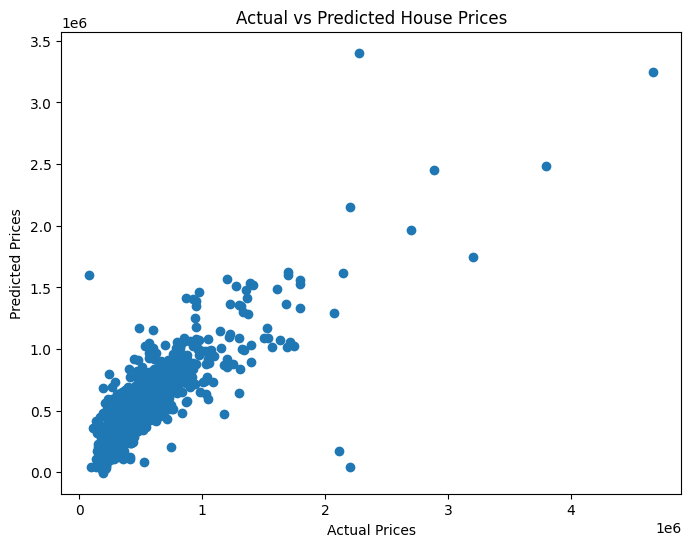

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [51]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']